# Mobile Games: A/B Testing & Player Retention

## 1. About the Data

### 1.1 Load the AB-test data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

%matplotlib inline

df = pd.read_csv('cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


### 1.2 Check missing values

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


No miising values in this dataset, no need to clean

### 1.3 Count the number of players in each group

In [3]:
df.groupby('version').count()

,userid,sum_gamerounds,retention_1,retention_7
version,,,,
gate_30,44700,44700,44700,44700
gate_40,45489,45489,45489,45489


The number of players is roughly the same in the control and test group.

## 2. Analyze Player Behavior

<Axes: >

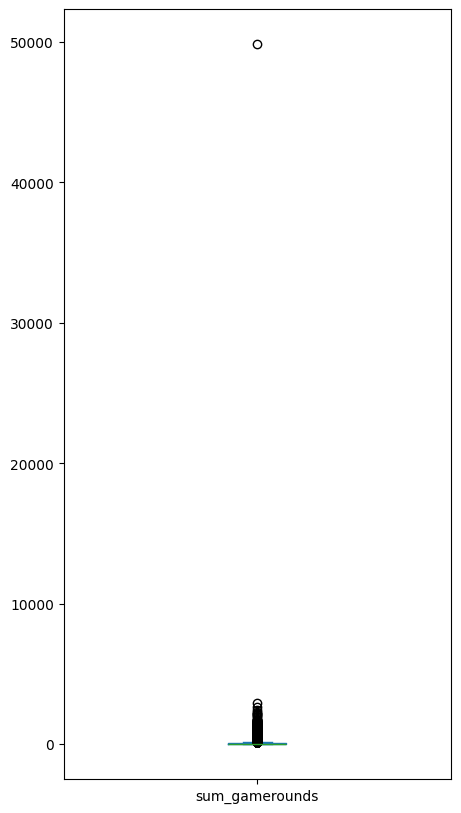

In [4]:
df['sum_gamerounds'].plot.box(figsize=(5,10))

In [5]:
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

In [6]:
plot_df = df.groupby('sum_gamerounds')['userid'].count()
plot_df

sum_gamerounds
0        3994
1        5538
2        4606
3        3958
4        3629
         ... 
2294        1
2438        1
2640        1
2961        1
49854       1
Name: userid, Length: 942, dtype: int64

Text(0.5, 0, '# Game rounds')

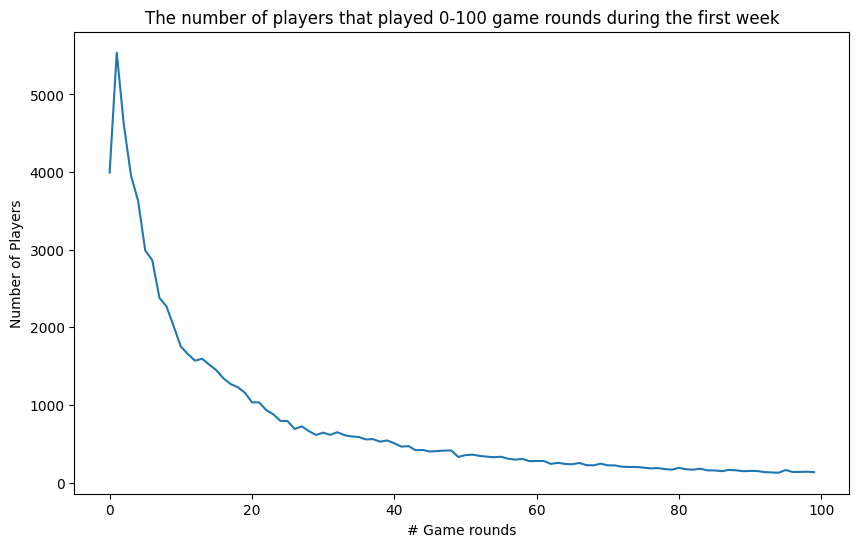

In [7]:
# Plot the distribution of players that played 0 to 100 game rounds during their first week playing the game.

ax = plot_df[:100].plot(figsize=(10,6))
ax.set_title("The number of players that played 0-100 game rounds during the first week")
ax.set_ylabel("Number of Players")
ax.set_xlabel('# Game rounds')

## 3. Comparing 1-day Retention

### Overall 1-day retention

In [8]:
df['retention_1'].sum() / df['retention_1'].count()

np.float64(0.4452095044850259)

Less than half of the players come back one day after installing the game

### 1-day retention for each AB-group

In [9]:
df.groupby('version')['retention_1'].mean()

version
gate_30    0.448188
gate_40    0.442283
Name: retention_1, dtype: float64

There was a slight decrease in 1-day retention when the gate was moved to level 40 (44.2%) compared to the control when it was at level 30 (44.8%)

### Bootstrapping

In [10]:
df.sample(frac = 1,replace = True)

,userid,version,sum_gamerounds,retention_1,retention_7
29893,3328351,gate_30,88,True,True
16146,1793989,gate_40,7,False,False
53766,5969866,gate_30,5,False,False
37369,4136822,gate_30,9,True,False
58116,6432808,gate_40,39,False,True
...,...,...,...,...,...
85715,9497689,gate_40,31,False,False
5877,649061,gate_30,8,False,False
66086,7318035,gate_40,14,False,False
32026,3561458,gate_30,2,False,False


In [11]:
df.sample(frac = 1,replace = True).groupby('version')['retention_1'].mean()

version
gate_30    0.444871
gate_40    0.439010
Name: retention_1, dtype: float64

<Axes: ylabel='Density'>

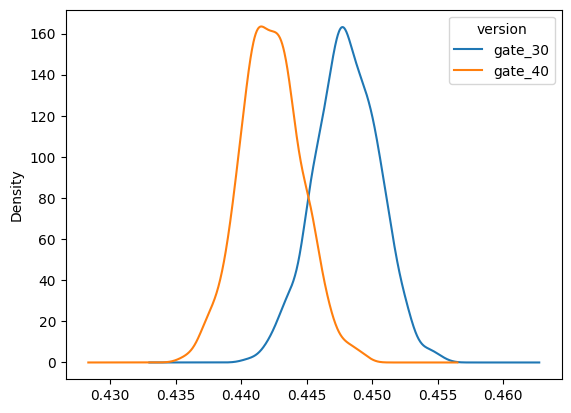

In [12]:
# Creating an list with bootstrapped means for each AB-group
boot_1d = []
for i in range(1000):
    boot_mean = df.sample(frac = 1,replace = True).groupby('version')['retention_1'].mean()
    boot_1d.append(boot_mean)

# Transforming the list to a DataFrame
boot_1d = pd.DataFrame(boot_1d)

# A Kernel Density Estimate plot of the bootstrap distributions
boot_1d.plot(kind='density')

Probability that 1-day retention is greater when the gate is at level 30: 0.96


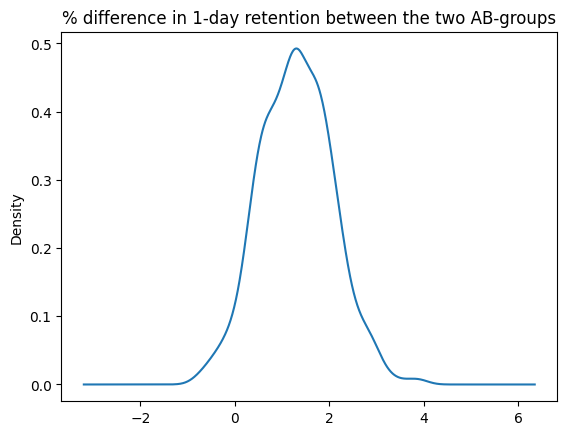

In [13]:
# Adding a column with the % difference between the two AB-groups
boot_1d['diff'] = (boot_1d.gate_30 - boot_1d.gate_40)/boot_1d.gate_40*100

# Ploting the bootstrap % difference
ax = boot_1d['diff'].plot(kind='density')
ax.set_title('% difference in 1-day retention between the two AB-groups')

# Calculating the probability that 1-day retention is greater when the gate is at level 30
print('Probability that 1-day retention is greater when the gate is at level 30:',(boot_1d['diff'] > 0).mean())

From this chart, we can see that the most likely % difference is around 1% - 2%, and that 95% of the distribution is above 0%, in favor of a gate at level 30.

## 4. Comparing 7-day Retention

In [14]:
df.groupby('version')['retention_7'].mean()

version
gate_30    0.190201
gate_40    0.182000
Name: retention_7, dtype: float64

Probability that 7-day retention is greater when the gate is at level 30: 1.0


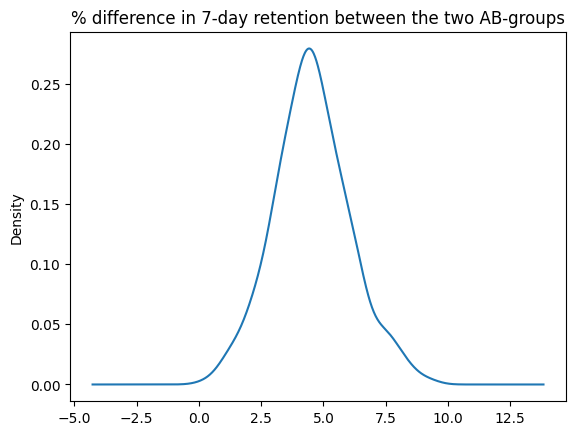

In [15]:
# Creating a list with bootstrapped means for each AB-group
boot_7d = []
for i in range(500):
    boot_mean = df.sample(frac=1,replace=True).groupby('version')['retention_7'].mean()
    boot_7d.append(boot_mean)

# Transforming the list to a DataFrame
boot_7d = pd.DataFrame(boot_7d)

# Adding a column with the % difference between the two AB-groups
boot_7d['diff'] = (boot_7d.gate_30 - boot_7d.gate_40)/boot_7d.gate_40*100

# Ploting the bootstrap % difference
ax = boot_7d['diff'].plot(kind='density')
ax.set_title('% difference in 7-day retention between the two AB-groups')

# Calculating the probability that 7-day retention is greater when the gate is at level 30
print('Probability that 7-day retention is greater when the gate is at level 30:',(boot_7d['diff'] > 0).mean())

## Bonus 1 - EDA-correlation

**[method1]**

In [18]:
import seaborn as sns

In [16]:
df_corr = df[['sum_gamerounds', 'retention_1', 'retention_7']].copy()

corr_matrix = df_corr.corr()
corr_matrix

,sum_gamerounds,retention_1,retention_7
sum_gamerounds,1.000000,0.197603,0.279288
retention_1,0.197603,1.000000,0.327401
retention_7,0.279288,0.327401,1.000000


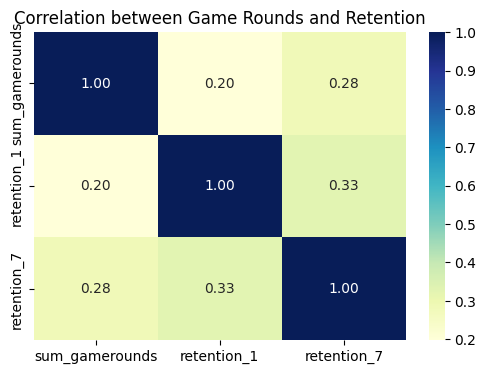

In [19]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation between Game Rounds and Retention')
plt.show()


We calculated the Pearson correlation between `sum_gamerounds`, `retention_1`, and `retention_7`.  

**Key insights:**
- `sum_gamerounds` has a **positive correlation** with both 1-day and 7-day retention:
  - Players who play more rounds during the first week are **more likely to be retained**, both on Day 1 and Day 7.
- The correlation is stronger for **7-day retention (0.28)** than for 1-day (0.20), which makes sense: committed players who continue for a week tend to have played more.
- There is also a **moderate correlation (0.33)** between Day-1 and Day-7 retention, meaning players who return on Day 1 are more likely to still be active on Day 7.

**[method2]**

In [20]:
def assign_ret_group(row):
    if row['retention_1'] and row['retention_7']:
        return 'Ret_1 & Ret_7'
    elif row['retention_1'] and not row['retention_7']:
        return 'Ret_1 only'
    elif not row['retention_1'] and row['retention_7']:
        return 'Ret_7 only'
    else:
        return 'No Retention'

df['ret_group'] = df.apply(assign_ret_group, axis=1)

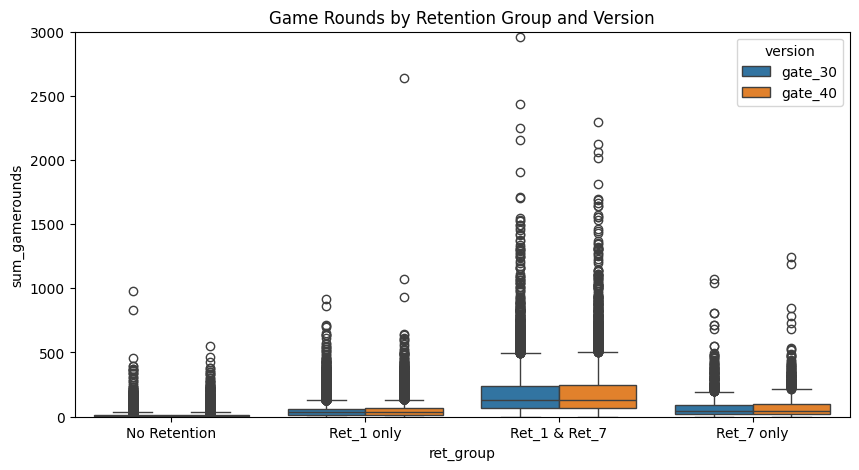

In [22]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='ret_group', y='sum_gamerounds', hue='version', data=df)
plt.title('Game Rounds by Retention Group and Version')
plt.ylim(0, 3000)
plt.show()

## Bonus 2 - 1 day retention-Z test

Assume： gate_40 does not have higher 1 day retention rate than the gate_30 at 5% Type I error. So the hypothesis woule be:

**null:** **$gate_{40}$** - **$gate_{30}$** <=0

**alternative:** **$gate_{40}$** - **$gate_{30}$** >0

#### [method1: formula]

In [16]:
n_40 = len(df[df.version == 'gate_40'])
n_30 = len(df[df.version == 'gate_30'])

In [17]:
day1_40 = df[df.version == 'gate_40'].retention_1.sum()
day1_30 = df[df.version == 'gate_30'].retention_1.sum()

In [18]:
p1_day1 = day1_40 / n_40
p0_day1 = day1_30 / n_30

In [19]:
def z_test(p1, p0, n1, n0):
    delta = p1 - p0
    p = (p1 * n1 + p0 * n0) / (n1 + n0)
    return delta / np.sqrt(p * (1 - p) * (1/n1 + 1/n0))

In [20]:
z1_formula = z_test(p1_day1, p0_day1, n_40, n_30)
p1_formula = 1 - norm.cdf(z1_formula)

In [26]:
z1_formula, p1_formula

(np.float64(-1.7840862247974725), np.float64(0.9627951723515404))

#### [method2: package]

In [25]:
z1_package, p1_package = sm.stats.proportions_ztest([day1_40, day1_30],[n_40, n_30],alternative='larger')
z1_package, p1_package

(np.float64(-1.7840862247974725), np.float64(0.9627951723515404))

At the 5% significance level, we fail to reject the null hypothesis. There is no statistical evidence that gate_40 improves 1-day retention compared to gate_30.

## 7 day retention-Z test

Assume： gate_40 does not have higher 1 day retention rate than the gate_30 at 5% Type I error. So the hypothesis woule be:

**null:** **$gate_{40}$** - **$gate_{30}$** <=0

**alternative:** **$gate_{40}$** - **$gate_{30}$** >0

#### [method1: formula]

In [27]:
day7_40 = df[df.version == 'gate_40'].retention_7.sum()
day7_30 = df[df.version == 'gate_30'].retention_7.sum()

In [28]:
p1_day7 = day7_40 / n_40
p0_day7 = day7_30 / n_30

In [29]:
z7_formula = z_test(p1_day7, p0_day7, n_40, n_30)
p7_formula = 1 - norm.cdf(z7_formula)
z7_formula, p7_formula

(np.float64(-3.164358912748191), np.float64(0.9992228750121929))

#### [method2: package]

In [30]:
z7_package, p7_package = sm.stats.proportions_ztest([day7_40, day7_30],[n_40, n_30],alternative='larger')
z7_package, p7_package

(np.float64(-3.164358912748191), np.float64(0.9992228750121929))

At the 5% significance level, we fail to reject the null hypothesis. There is no statistical evidence that gate_40 improves 7-day retention compared to gate_30.

## Bonus 3 - 1 day retention-T test

#### [method1: formula]

In [34]:
from scipy.stats import t

In [31]:
converted_30_r1 = df[df['version'] == 'gate_30']['retention_1'].astype(int)
converted_40_r1 = df[df['version'] == 'gate_40']['retention_1'].astype(int)

In [32]:
p0_r1 = converted_30_r1.mean()  
p1_r1 = converted_40_r1.mean()  

n0_r1 = len(converted_30_r1)
n1_r1 = len(converted_40_r1)

In [35]:
def t_test(p1, p0, n1, n0):
    se = np.sqrt((p1 * (1 - p1)) / n1 + (p0 * (1 - p0)) / n0)
    t_stat = (p1 - p0) / se
    return t_stat

t_stat_r1 = t_test(p1_r1, p0_r1, n1_r1, n0_r1)
df_r1 = n1_r1 + n0_r1 - 2  # degrees of freedom
p_value_r1 = 1 - t.cdf(t_stat_r1, df=df_r1)

In [36]:
t_stat_r1, p_value_r1

(np.float64(-1.7840972718297632), np.float64(0.9627943892602068))

#### [method2: package]

In [40]:
from scipy.stats import ttest_ind

stat_r1, pval_r1 = ttest_ind(converted_40_r1, converted_30_r1, equal_var=False)
stat_r1, pval_r1

(np.float64(-1.7840774867039824), np.float64(0.07441443713953827))

In [41]:
pval_r1_one_tailed = pval_r1 / 2 if stat_r1 > 0 else 1 - pval_r1 / 2
pval_r1_one_tailed

np.float64(0.9627927814302308)

## 7 day retention-T test

#### [method1: formula]

In [37]:
converted_30_r7 = df[df['version'] == 'gate_30']['retention_7'].astype(int)
converted_40_r7 = df[df['version'] == 'gate_40']['retention_7'].astype(int)

In [38]:
p0_r7 = converted_30_r7.mean()  
p1_r7 = converted_40_r7.mean() 

n0_r7 = len(converted_30_r7)
n1_r7 = len(converted_40_r7)

In [39]:
def t_test(p1, p0, n1, n0):
    se = np.sqrt((p1 * (1 - p1)) / n1 + (p0 * (1 - p0)) / n0)
    t_stat = (p1 - p0) / se
    return t_stat

t_stat_r7 = t_test(p1_r7, p0_r7, n1_r7, n0_r7)
df_r7 = n1_r7 + n0_r7 - 2 
p_value_r7 = 1 - t.cdf(t_stat_r7, df=df_r7)
t_stat_r7, p_value_r7

(np.float64(-3.1640640401490985), np.float64(0.9992218290437873))

#### [method2: package]

In [42]:
stat_r7, pval_r7 = ttest_ind(converted_40_r7, converted_30_r7, equal_var=False)
stat_r7, pval_r7

(np.float64(-3.164028946774232), np.float64(0.001556530181006654))

In [43]:
pval_r7_one_tailed = pval_r7 / 2 if stat_r7 > 0 else 1 - pval_r7 / 2
pval_r7_one_tailed

np.float64(0.9992217349094967)